# Caso de Estudio 2 — Diagnóstico del sistema de puntos MiMcDonald's Guatemala

**Machine Learning Engineering (CC3105)** · Universidad del Valle de Guatemala · Septiembre 2026

**Equipo consultor:** Diego Linares · Andy Fuentes · Christian Echeverria · Diederich Solis

**Repositorio:** [https://github.com/DiegoLinares11/MLOPS-Caso-de-estudio-2](https://github.com/DiegoLinares11/MLOPS-Caso-de-estudio-2)

---

## 1. Resumen de la situación

McDonald's Guatemala (operado por **McDonald's Mesoamérica**, 126 restaurantes) lanzó el
**27 de agosto de 2025** su programa de lealtad **MiMcDonald's**, que reemplazó a *Puntos
McDelivery*. Quienes diseñaron el sistema ya no están en la empresa y **no existe documentación**.
Nos contrataron para diagnosticarlo y proponer optimizaciones en una semana.

**Qué hicimos**, siguiendo **CRISP-DM**:

1. **Reconstruimos las reglas** del programa desde fuentes públicas (Términos y Condiciones
   oficiales): 22 reglas y 8 vacíos de documentación.
2. **Inferimos la arquitectura de datos actual** y la documentamos en un diagrama.
3. Construimos una **réplica en miniatura** con arquitectura **medallion** (Bronze → Silver →
   Gold) en **Databricks Free Edition**. Como el cliente no entregó datos, simulamos los 6
   sistemas origen con **datos sintéticos** que respetan las reglas y traen **18 tipos de error
   inyectados a propósito**.
4. Hicimos una **prueba funcional (POC)**: **39 de 39 pruebas OK**. El pipeline calcula los
   saldos de 5,150 clientes con **0 diferencias** contra una contabilidad independiente, y
   detecta los 17 tipos de error con **0 faltantes y 0 falsas alarmas**.
5. Integramos un **modelo de ML** (recomendador de recompensas) que acierta la recompensa que el
   cliente canjea **39 % más** que recomendar lo más popular.

**Hallazgos principales:**

| # | Hallazgo | Evidencia |
|---|---|---|
| 1 | **El tope de 1,000 puntos diarios castiga a McDelivery**, el canal que más gasta | Pierde el **39 %** de sus puntos (vs ~17 % en caja) |
| 2 | **Breakage alto**: muchos puntos vencen sin usarse | 8.1 M puntos vencidos, el 44 % de lo acumulado por compras |
| 3 | La **app no valida el mínimo de canje** de McDelivery (Q50/Q60) | 33 canjes bajo el mínimo |
| 4 | **El catálogo no atiende a todos los segmentos**: desayuno y familias no tienen recompensa accesible de su gusto | El café (única recompensa barata de desayuno) salió del catálogo en junio |
| 5 | **No hay verificación de identidad**: una persona puede abrir varias cuentas y cobrar la bienvenida varias veces | 150 cuentas duplicadas detectadas |
| 6 | La **tasa de conversión del programa anterior no está publicada** (1 pt/Q → 10 pts/Q) | Riesgo reputacional y contable |

## 2. Metodología

| Fase CRISP-DM | Qué respondimos | Entregable en el repositorio |
|---|---|---|
| 1. Entendimiento del negocio | ¿Qué reglas tiene el programa? | `docs/01_entendimiento_negocio.md` |
| 2. Entendimiento de los datos | ¿Qué sistemas generan datos y con qué problemas? | `docs/02_entendimiento_datos.md`, `diagramas/arquitectura.md` |
| 3. Preparación de datos | Réplica medallion | `notebooks/00` a `03`, `docs/03_preparacion_datos.md` |
| 4. Modelado | Recomendador de recompensas | `notebooks/04_recomendador.py`, `docs/04_modelado.md` |
| 5. Evaluación | POC contra la hoja de respuestas | `notebooks/05_evaluacion.py`, `docs/05_evaluacion.md` |
| 6. Despliegue | Recomendaciones y este reporte | `reporte/` |

**Herramientas:** Databricks Free Edition (Serverless, Unity Catalog, Volumes, tablas Delta,
MLflow), PySpark, pandas, scikit-learn, Mermaid y GitHub (Git folders de Databricks).

## 3. Diagnóstico del sistema actual

### 3.1 Reglas reconstruidas (principales)

| ID | Regla | Valor |
|---|---|---|
| R1–R2 | Acumulación | 10 puntos por cada Q1, redondeando hacia arriba (precios con IVA) |
| R4–R5 | No acumulan | Donaciones y productos canjeados |
| R6–R7 | Canales | Acumulan: mostrador, AutoMac, kioscos, McCafé, Centros de Postre y la app. **No** acumulan: apps de terceros, Call Center y WhatsApp |
| R8 | Tope de acumulación | 1,000 puntos por día |
| R9 | Acreditación | Máximo 24 horas (indica procesamiento por lotes nocturno) |
| R10–R11 | Vencimiento | 365 días por lote, con aviso 30 días antes |
| R12–R13 | Límites de canje | 15,000 puntos por día y 3 ofertas por pedido |
| R14 | Canje irreversible | Los puntos no se devuelven aunque se anule la orden |
| R15 | Mínimo de compra para canjear en McDelivery | Q50 (desayuno) / Q60 (almuerzo y cena) |
| R16 | Catálogo | De 3,000 a 7,500 puntos; cambia sin previo aviso |
| R17 | Bienvenida | Quesoburguesa al registrarse y 1,000 puntos con la primera compra |
| R20 | Territorio | Solo Guatemala (la plataforma es compartida con Honduras) |
| R21 | Migración | Los puntos de Puntos McDelivery "se convierten automáticamente" |

### 3.2 Vacíos de documentación

| ID | Vacío | Supuesto usado en la réplica |
|---|---|---|
| H1 | No se publica la tasa de conversión del programa anterior | ×10 (conserva el valor en quetzales) |
| H2 | No es explícito si el IVA suma puntos | Sí, se usa el total pagado |
| H3 | No se dice qué pasa con los puntos de una orden anulada | No acumulan |
| H4 | La acreditación en 24 h sugiere procesamiento batch | Pipeline diario |
| H5 | El tope diario no define la zona horaria ni el orden de corte | Día de Guatemala, orden cronológico |
| H6 | "Dos correos = dos cuentas" y el teléfono es opcional | Se detectan cuentas de la misma persona |
| H7 | La recompensa más barata exige Q300 y al menos 3 días de compra | Se analiza en Gold |
| H8 | La nube del franquiciado no es pública (Google Cloud es del corporativo) | Se reporta como supuesto |

### 3.3 Arquitectura de datos actual (inferida)

Borde punteado = inferido; rojo = canales que no acumulan. Las compras en restaurante pasan por
el POS y llegan al motor de lealtad **por lotes**; las de la app entran directo. El POS solo
conoce el código QR del cliente, no su identidad.

![Arquitectura actual](imagenes/arquitectura_actual.png)

## 4. Réplica en miniatura (medallion en Databricks)

### 4.1 Datos sintéticos

El notebook `00_generador_datos.py` simula **6 fuentes** con formatos distintos, como en la
realidad: POS (CSV diario con hora local), app (JSON anidado con hora UTC y campos en inglés),
CRM (arreglo JSON), maestro de restaurantes, catálogo versionado y saldos del programa anterior.

- 5,250 cuentas, 30 restaurantes, 13 meses (27-ago-2025 → 20-sep-2026), **56,239 tickets**.
- **18 errores inyectados** (archivos reenviados, canales mal escritos, comas decimales, códigos
  inexistentes, tickets anulados, eventos duplicados, cuentas duplicadas, saldos negativos…).
- Cada cliente tiene un **perfil de gustos** oculto (res, pollo, desayuno, café y postres,
  familia).
- El generador lleva **su propia contabilidad de puntos** en Python puro y la guarda como **hoja
  de respuestas** (Volume `control`), que el pipeline nunca lee.

### 4.2 Arquitectura de la réplica

![Réplica medallion](imagenes/arquitectura_replica.png)

| Capa | Qué hace | Tablas |
|---|---|---|
| **Landing** | Archivos tal como los "envían" los sistemas | Volume `landing` |
| **Bronze** | Cada fuente como tabla, **sin corregir nada** (todo texto) + archivo de origen y fecha de ingesta | 6 tablas `bronze_*` |
| **Silver** | Limpia, tipa, deduplica y **unifica POS y app**; hora de Guatemala; lo irrecuperable va a cuarentena con su motivo | 8 tablas `silver_*` |
| **Gold** | Aplica las **reglas del programa**: ledger de puntos, saldos, vencimientos FIFO, KPIs, violaciones | 8 tablas `gold_*` |

**Principio clave:** Silver describe *qué pasó* y Gold decide *qué significa*. Si cambia una regla
del programa, solo se toca Gold. **El saldo nunca se guarda: se calcula** sumando el ledger, así
cualquier saldo se puede auditar hasta la compra que lo originó.

## 5. Prueba funcional (POC) del sistema de puntos

### 5.1 Procedimiento

1. En Databricks: **Workspace → Create → Git folder** con la URL del repositorio.
2. Correr en orden, en Serverless: `00_generador_datos` → `01_bronze` → `02_silver` → `03_gold`
   → `04_recomendador` → `05_evaluacion`.
3. `05_evaluacion` compara todo contra la hoja de respuestas y guarda el resultado en la tabla
   `eval_resultados_poc`.

### 5.2 Código clave

**Tope diario (R8) sin ciclos.** Con la suma acumulada `S` de las compras del día, cada compra
recibe `min(1000, S) − min(1000, S − puntos)`:

```python
mismo_dia = (Window.partitionBy("customer_id", "fecha_gt")
                   .orderBy("fecha_hora_gt", "transaccion_id")
                   .rowsBetween(Window.unboundedPreceding, Window.currentRow))
compras = (compras
    .withColumn("suma_dia", F.sum("puntos_calculados").over(mismo_dia))
    .withColumn("puntos_otorgados",
                F.least(tope, F.col("suma_dia"))
                - F.least(tope, F.col("suma_dia") - F.col("puntos_calculados"))))
```

**Vencimiento por lotes con FIFO (R10).** Es secuencial por naturaleza (lo que vence depende de
lo que consumieron los canjes anteriores), así que se resuelve por cliente con `applyInPandas`,
que Spark reparte en paralelo:

```python
def procesar_lotes(pdf):
    lotes, salida = [], []                      # lote = [fecha, puntos_restantes]
    for fila in pdf.sort_values(["fecha_gt", "fecha_hora_gt", "prioridad"]).itertuples():
        vencer(fila.fecha_gt)                   # lotes con fecha + 365 <= hoy
        if fila.puntos > 0:
            lotes.append([fila.fecha_gt, fila.puntos])      # abono: nace un lote
        else:
            costo = -fila.puntos                            # canje: consume lo más viejo
            for lote in lotes:
                usar = min(lote[1], costo); lote[1] -= usar; costo -= usar
    ...

lotes = movimientos.groupBy("customer_id").applyInPandas(procesar_lotes, schema=ESQUEMA_LOTES)
```

**Evaluación registro por registro** (no solo conteos, para que dos errores no se compensen):

```python
for error in detectados:
    esp, det = esperados[error], detectados[error]
    faltantes, falsas_alarmas = len(esp - det), len(det - esp)
```

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

AZUL, NARANJA, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
TINTA, TINTA2, GRIS, REJILLA, EJE = "#0b0b0b", "#52514e", "#b9b7b0", "#e1e0d9", "#c3c2b7"
plt.rcParams.update({
    "figure.dpi": 130, "font.size": 10, "axes.edgecolor": EJE, "axes.labelcolor": TINTA2,
    "xtick.color": TINTA2, "ytick.color": TINTA2, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": REJILLA, "grid.linewidth": 0.6, "axes.axisbelow": True,
    "axes.titleweight": "bold", "axes.titlesize": 11, "axes.titlecolor": TINTA,
})

def tabla_md(df):
    display(Markdown(df.to_markdown(index=False)))

poc = pd.read_csv("datos/eval_resultados_poc.csv")
resumen = (poc.assign(ok=poc["ok"].astype(str).str.lower() == "true")
              .groupby("parte")["ok"].agg(["sum", "count"]).reset_index())
nombres = {"A": "A. Pruebas funcionales por regla", "B": "B. Calidad de datos (registro por registro)",
           "C": "C. Saldos vs hoja de respuestas", "D": "D. Recomendador vs gustos reales"}
resumen["Parte"] = resumen["parte"].map(nombres)
resumen["Pruebas OK"] = resumen["sum"].astype(str) + " / " + resumen["count"].astype(str)
tabla_md(resumen[["Parte", "Pruebas OK"]])
print(f"TOTAL: {int(resumen['sum'].sum())} de {int(resumen['count'].sum())} pruebas OK")

| Parte                                       | Pruebas OK   |
|:--------------------------------------------|:-------------|
| A. Pruebas funcionales por regla            | 12 / 12      |
| B. Calidad de datos (registro por registro) | 18 / 18      |
| C. Saldos vs hoja de respuestas             | 8 / 8        |
| D. Recomendador vs gustos reales            | 1 / 1        |

TOTAL: 39 de 39 pruebas OK


### 5.3 Resultados

**Parte A · Reglas.** Cada regla se probó sobre **todos** sus casos reales, con 0 fallas. Ejemplos:
Q12.75 × 10 = 127.5 → **128** puntos (R2); el cliente C002481 calculó 5,430 puntos en un día y
recibió **1,000** (R8); 158 canjes de Big Tasty a 7,000 puntos y 87 a 7,500 según la fecha
(R16); 1,378 tickets de canales excluidos con cliente identificado y ninguno acumuló (R7).

**Parte B · Calidad de datos.** Silver detectó exactamente los registros con error:

In [2]:
calidad = pd.read_csv("datos/calidad_errores.csv")
calidad.columns = ["Error", "Inyectados", "Detectados", "Aciertos", "Faltantes", "Falsas alarmas"]
tabla_md(calidad)

| Error   |   Inyectados |   Detectados |   Aciertos |   Faltantes |   Falsas alarmas |
|:--------|-------------:|-------------:|-----------:|------------:|-----------------:|
| E2      |         2454 |         2454 |       2454 |           0 |                0 |
| E3      |         1494 |         1494 |       1494 |           0 |                0 |
| E4      |          998 |          998 |        998 |           0 |                0 |
| E5      |          167 |          167 |        167 |           0 |                0 |
| E6      |          445 |          445 |        445 |           0 |                0 |
| E7      |          946 |          946 |        946 |           0 |                0 |
| E8      |          237 |          237 |        237 |           0 |                0 |
| E9      |          151 |          151 |        151 |           0 |                0 |
| E10     |           33 |           33 |         33 |           0 |                0 |
| E11     |           55 |           55 |         55 |           0 |                0 |
| E12     |          272 |          272 |        272 |           0 |                0 |
| E13     |          150 |          150 |        150 |           0 |                0 |
| E14     |          990 |          990 |        990 |           0 |                0 |
| E15     |          100 |          100 |        100 |           0 |                0 |
| E16     |            3 |            3 |          3 |           0 |                0 |
| E17     |          252 |          252 |        252 |           0 |                0 |
| E18     |            7 |            7 |          7 |           0 |                0 |

**Parte C · Saldos.** Gold (Spark) contra la contabilidad independiente del generador (Python
puro), cliente por cliente:

In [3]:
saldos = pd.read_csv("datos/saldos_vs_esperado.csv")
saldos["metrica"] = saldos["metrica"].str.replace("puntos_", "").str.replace("_", " ")
for c in ["total_esperado", "total_gold"]:
    saldos[c] = saldos[c].map("{:,}".format)
saldos.columns = ["Métrica", "Total esperado", "Total Gold", "Clientes con diferencia (de 5,150)"]
tabla_md(saldos)

| Métrica           |   Total esperado |   Total Gold |   Clientes con diferencia (de 5,150) |
|:------------------|-----------------:|-------------:|-------------------------------------:|
| acumulados        |       18,581,394 |   18,581,394 |                                    0 |
| bienvenida        |        4,336,000 |    4,336,000 |                                    0 |
| migrados          |       17,835,600 |   17,835,600 |                                    0 |
| canjeados         |       20,729,000 |   20,729,000 |                                    0 |
| vencidos          |        8,097,012 |    8,097,012 |                                    0 |
| perdidos por tope |        5,277,554 |    5,277,554 |                                    0 |
| saldo final       |       11,926,982 |   11,926,982 |                                    0 |

## 6. Hallazgos del diagnóstico

### 6.1 El tope diario castiga a los pedidos grandes

Con 10 puntos por quetzal y un tope de 1,000 puntos diarios, **todo lo que se gaste arriba de Q100
en un día no genera puntos**. En McDelivery el 67 % de los pedidos pasa de Q100:

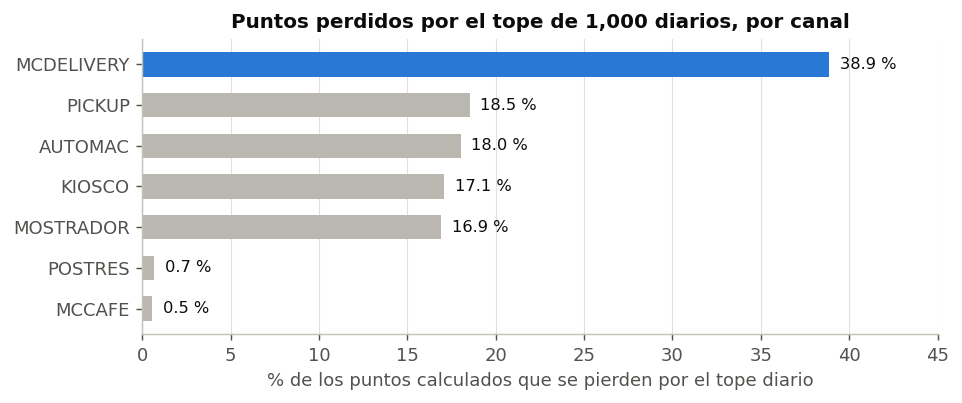

In [4]:
canal = pd.read_csv("datos/kpis_canal.csv")
canal = canal[canal["participa_en_programa"].astype(str).str.lower() == "true"].sort_values("pct_puntos_perdidos_por_tope")
fig, ax = plt.subplots(figsize=(7.5, 3.2))
colores = [AZUL if c == "MCDELIVERY" else GRIS for c in canal["canal"]]
ax.barh(canal["canal"], canal["pct_puntos_perdidos_por_tope"] * 100, color=colores, height=0.6)
for y, v in enumerate(canal["pct_puntos_perdidos_por_tope"] * 100):
    ax.text(v + 0.6, y, f"{v:.1f} %", va="center", color=TINTA, fontsize=9)
ax.set_xlabel("% de los puntos calculados que se pierden por el tope diario")
ax.set_title("Puntos perdidos por el tope de 1,000 diarios, por canal")
ax.grid(axis="y", visible=False); ax.set_xlim(0, 45)
plt.tight_layout(); plt.show()

### 6.2 Breakage: los puntos migrados vencen en masa al año

Los puntos migrados del programa anterior se abonaron en agosto y septiembre de 2025 y **vencen
todos juntos un año después**. Es un pasivo que desaparece para la empresa, pero también una mala
experiencia para los clientes más antiguos:

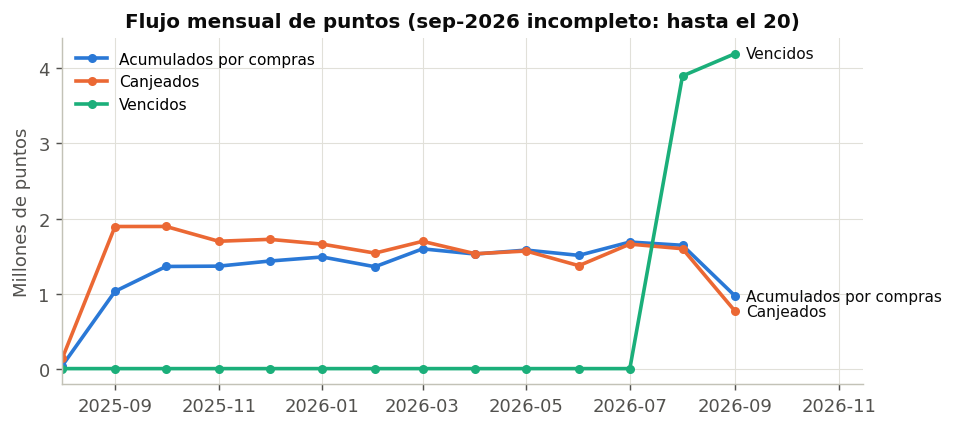

In [5]:
mes = pd.read_csv("datos/kpis_mensuales.csv", parse_dates=["mes"])
fig, ax = plt.subplots(figsize=(7.5, 3.4))
series = [("puntos_acumulados", "Acumulados por compras", AZUL),
          ("puntos_canjeados", "Canjeados", NARANJA),
          ("puntos_vencidos", "Vencidos", AQUA)]
for col, nombre, color in series:
    ax.plot(mes["mes"], mes[col] / 1e6, color=color, linewidth=2, marker="o", markersize=4, label=nombre)
    ax.annotate(nombre, (mes["mes"].iloc[-1], mes[col].iloc[-1] / 1e6), xytext=(6, 0),
                textcoords="offset points", va="center", color=TINTA, fontsize=8.5)
ax.set_ylabel("Millones de puntos"); ax.set_title("Flujo mensual de puntos (sep-2026 incompleto: hasta el 20)")
ax.legend(frameon=False, loc="upper left", fontsize=8.5)
ax.set_xlim(mes["mes"].min(), mes["mes"].max() + pd.Timedelta(days=75))
plt.tight_layout(); plt.show()

### 6.3 Otros hallazgos

| Hallazgo | Dato | Riesgo |
|---|---|---|
| La app deja canjear en McDelivery sin llegar al mínimo (R15) | 33 canjes | Fuga de beneficios; indica que la regla no está implementada en la app |
| Los canales de terceros mueven pedidos grandes que el programa no ve | PedidosYa y Uber Eats: ticket de ~Q135, 0 clientes identificados | Se pierde el conocimiento de los clientes de mayor gasto |
| Cuentas duplicadas de la misma persona | 150 cuentas (mismo nombre y teléfono) | Abuso de la bienvenida (quesoburguesa + 1,000 puntos) |
| Saldos del programa anterior sin reclamar | 252 correos nunca se registraron | Pasivo pendiente sin fecha de vencimiento clara |
| Datos corruptos en la app | 55 eventos sin `customer_id`, `store_id` o `created_at` | Compras que nunca acumulan y generan reclamos |

## 7. Propuesta: modelo de ML integrado en el pipeline

### 7.1 Recomendador de recompensas

**Pregunta:** ¿qué recompensa le mostramos a cada cliente en la app? Es lo que McDonald's hace a
nivel corporativo con Dynamic Yield.

**Diseño de dos etapas:** (1) candidatos = recompensas vigentes en el catálogo; (2) un modelo de
*gradient boosting* ordena los candidatos combinando **gusto** (qué compra), **costo y saldo**
(¿le alcanza?), **hora** y **popularidad**. Se registra en **MLflow** y en **Unity Catalog**, y
escribe `gold_recomendaciones` con un mensaje listo para la app ("Te faltan 500 puntos para tu
McFlurry").

**Decisiones de ingeniería:**
- **Validación temporal:** variables hasta el 20-jun-2026 y etiqueta = canjes del 20-jun al
  20-sep. Nada del futuro entra a las variables (fuga de información).
- **Primero los baselines:** con los datos v1 ningún modelo superaba a "recomendar lo más
  popular". Se detectó que faltaban gustos en los datos y se generó la v2.
- **El modelo evaluado es el que se despliega:** se fijó `early_stopping=False`, porque
  scikit-learn lo activa solo con más de 10,000 filas y el modelo de producción se habría
  entrenado distinto al evaluado.

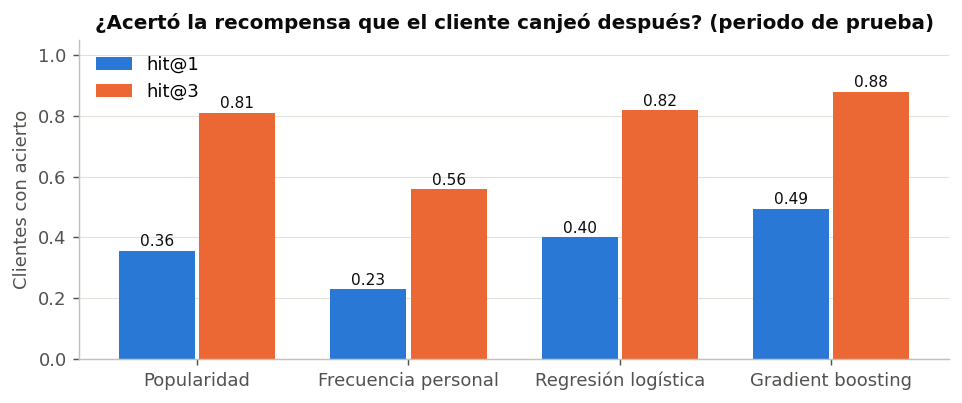

In [6]:
est = pd.read_csv("datos/recomendador_estrategias.csv")
nombres = {"baseline_popularidad": "Popularidad", "baseline_frecuencia": "Frecuencia personal",
           "regresion_logistica": "Regresión logística", "gradient_boosting": "Gradient boosting"}
est["estrategia"] = est["estrategia"].map(nombres)
fig, ax = plt.subplots(figsize=(7.5, 3.2))
x = range(len(est)); w = 0.36
b1 = ax.bar([i - w/2 - 0.01 for i in x], est["hit_at_1"], w, color=AZUL, label="hit@1")
b2 = ax.bar([i + w/2 + 0.01 for i in x], est["hit_at_3"], w, color=NARANJA, label="hit@3")
for barras in (b1, b2):
    for b in barras:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.015, f"{b.get_height():.2f}",
                ha="center", fontsize=8.5, color=TINTA)
ax.set_xticks(list(x)); ax.set_xticklabels(est["estrategia"])
ax.set_ylim(0, 1.05); ax.set_ylabel("Clientes con acierto")
ax.set_title("¿Acertó la recompensa que el cliente canjeó después? (periodo de prueba)")
ax.legend(frameon=False, loc="upper left"); ax.grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

El *gradient boosting* acierta la recompensa del banner principal (hit@1) **39 % más** que
recomendar lo más popular (0.495 vs 0.356).

**¿Aprendió los gustos reales?** El modelo nunca vio el segmento de gustos de cada cliente. Al
revelarlo, se mide si entre sus 3 recomendaciones hay alguna de su gusto:

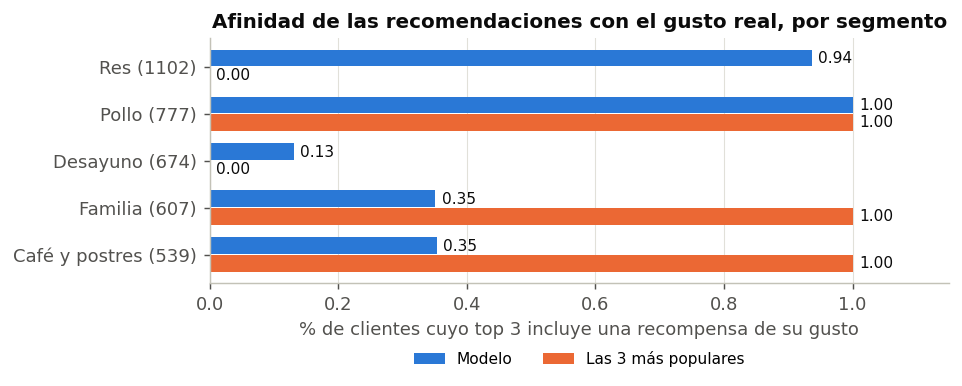

Total: modelo 0.62 vs las 3 más populares 0.52


In [7]:
seg = pd.read_csv("datos/recomendador_segmentos.csv").sort_values("clientes")
fig, ax = plt.subplots(figsize=(7.5, 3.2))
y = range(len(seg)); h = 0.36
ax.barh([i + h/2 + 0.01 for i in y], seg["modelo_top3"], h, color=AZUL, label="Modelo")
ax.barh([i - h/2 - 0.01 for i in y], seg["popular_top3"], h, color=NARANJA, label="Las 3 más populares")
for i, (m, p) in enumerate(zip(seg["modelo_top3"], seg["popular_top3"])):
    ax.text(m + 0.01, i + h/2, f"{m:.2f}", va="center", fontsize=8.5, color=TINTA)
    ax.text(p + 0.01, i - h/2, f"{p:.2f}", va="center", fontsize=8.5, color=TINTA)
etiquetas = {"RES": "Res", "POLLO": "Pollo", "DESAYUNO": "Desayuno", "FAMILIA": "Familia", "CAFE_POSTRE": "Café y postres"}
ax.set_yticks(list(y)); ax.set_yticklabels([f"{etiquetas[s]} ({c})" for s, c in zip(seg["segmento"], seg["clientes"])])
ax.set_xlim(0, 1.15); ax.set_xlabel("% de clientes cuyo top 3 incluye una recompensa de su gusto")
ax.set_title("Afinidad de las recomendaciones con el gusto real, por segmento")
ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.22), ncol=2, fontsize=8.5)
ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()
total_modelo = (seg["modelo_top3"] * seg["clientes"]).sum() / seg["clientes"].sum()
total_popular = (seg["popular_top3"] * seg["clientes"]).sum() / seg["clientes"].sum()
print(f"Total: modelo {total_modelo:.2f} vs las 3 más populares {total_popular:.2f}")

**Lectura:**
- El modelo **gana en total** y sobre todo en el segmento más grande (res), donde recomienda la
  quesoburguesa que la lista popular nunca muestra.
- Pierde en café/postres y familia porque la lista popular ya incluye el McFlurry.
- **El segmento desayuno queda desatendido por ambos.** No es un problema del algoritmo, sino del
  **catálogo**: las recompensas de desayuno cuestan 5,000 y 7,500 puntos, y la única barata (el
  café, 3,000) salió del catálogo en junio.
- Lo que más pesa en el modelo es el **costo** de la recompensa: predice bien lo que la gente
  canjea (lo barato). Si McDonald's quiere otro resultado (más visitas, mayor ticket), **el
  objetivo del modelo debe cambiar: es una decisión de negocio**.

### 7.2 Integración en el pipeline

![Integración del modelo](imagenes/integracion_ml.png)

| Aspecto | Propuesta |
|---|---|
| Inferencia | Nocturna, después de Gold (usa el saldo del día) |
| Reentrenamiento | Mensual o cuando cambie el catálogo; el modelo nuevo solo reemplaza al actual si supera su hit@1 **y** el de los baselines |
| Monitoreo | hit@1 semanal con los canjes reales, tasa de clic del banner y diversidad de recompensas recomendadas |
| Arranque en frío | Clientes con poca historia reciben la lista popular |
| Validación real | Prueba A/B: 50 % ve el catálogo actual y 50 % el recomendado, durante 30 días |
| Extensión con LLM | Un LLM (`ai_query()` en Databricks) redacta el mensaje personalizado; **no** decide qué recompensa ofrecer |

## 8. Propuestas de optimización

| Prioridad | Problema | Propuesta | Impacto esperado |
|---|---|---|---|
| Alta | El tope diario castiga a McDelivery (39 % de puntos perdidos) | Subir el tope o excluir McDelivery de él; como mínimo, avisar al cliente en la app | Retener a los clientes de mayor gasto |
| Alta | La app no valida el mínimo de canje (R15) | Validar en la app **y** en el motor de lealtad; auditar con la tabla de violaciones | Cerrar la fuga de beneficios |
| Alta | Cuentas duplicadas cobran la bienvenida | Verificar el teléfono (OTP) al registrarse y marcar cuentas con el mismo nombre y teléfono | Reducir el abuso |
| Media | Breakage alto y vencimientos masivos | Usar `gold_puntos_por_vencer` para avisar 30 días antes (R11) con una recompensa recomendada | Más canjes y mejor experiencia |
| Media | Segmentos sin recompensa accesible | Recompensa de desayuno de ~3,000 puntos y una de Cajita Feliz | Atender a ~1/3 de los clientes |
| Media | Terceros invisibles para el programa | Integrar el código de lealtad en PedidosYa/Uber Eats o dar puntos parciales | Conocer a los clientes de mayor ticket |
| Media | Reglas sin documentar | Adoptar estos documentos como documentación oficial y validar H1–H8 con el cliente | Reducir la dependencia de personas |
| Técnica | Pipeline por lotes completos | **Auto Loader** para ingesta incremental, `MERGE` en Gold, movimientos de `REVERSO` para anulaciones tardías, *expectations* de Lakeflow y orquestación con Lakeflow Jobs | Escala y menor costo |

## 9. Conclusiones

1. **El sistema se puede documentar y auditar.** Reconstruimos 22 reglas desde fuentes públicas,
   identificamos 8 vacíos y los resolvimos con supuestos explícitos que el cliente debe validar.
2. **La arquitectura medallion es la adecuada** para un programa de puntos: la acreditación en 24 h
   indica procesamiento por lotes, y separar Bronze (evidencia), Silver (limpieza) y Gold (reglas)
   permite auditar cualquier saldo y cambiar una regla sin tocar lo demás.
3. **El diseño del modelo de datos importa más que la herramienta.** Como los puntos vencen por
   lote, el saldo no puede ser un número guardado: tiene que calcularse desde un ledger.
4. **La réplica es confiable.** La POC pasó 39 de 39 pruebas: saldos idénticos en 5,150 clientes
   contra una implementación independiente y detección exacta de los 17 tipos de error.
5. **El ML sí aporta, pero no reemplaza las decisiones de negocio.** El recomendador supera al
   baseline, pero revela que el problema del segmento desayuno está en el catálogo, y que el
   objetivo del modelo (qué optimizar) lo debe decidir McDonald's.
6. **Limitación:** los datos son sintéticos. La POC demuestra que el pipeline aplica bien las
   reglas; el siguiente paso es validar las reglas y supuestos con el cliente y correr el pipeline
   con sus datos reales.

## 10. Referencias

1. McDonald's Guatemala. (s. f.). *Términos y Condiciones App de McDonald's® en Guatemala*.
   https://mcdonaldsdigital.com/GML/public/app/gt/terminos-y-condiciones
2. McDonald's Guatemala. (s. f.). *MiMcDonald's Guatemala*. https://www.mi.mcdonalds.com.gt/
3. Periódico Digital Centroamericano y del Caribe. (2025). *McDonald's lanza "MiMcDonald's", su
   nuevo programa de lealtad para recompensar a sus invitados*.
   https://newsinamerica.com/pdcc/noticias/gerenciales/2025/mcdonalds-lanza-mimcdonalds-su-nuevo-programa-de-lealtad-para-recompensar-a-sus-invitados/
4. Perspectiva. (2026). *McDonald's alcanza 126 restaurantes en Guatemala*.
   https://perspectiva.gt/empresa/mcdonalds-alcanza-126-restaurantes-guatemala-2026/
5. L'Express Franchise. (2026). *McDonald's llega a 126 restaurantes en Guatemala: quién es el
   dueño*. https://lexpress-franchise.com/latam/ultimas-noticias/mcdonalds-llega-126-restaurantes-guatemala-quien-es-dueno/
6. McDonald's Guatemala. (s. f.). *Puntos McDelivery*. https://puntosmcdelivery.mcdonalds.com.gt/
7. McDonald's Corporation. (2023). *McDonald's announces new targets for development, loyalty
   membership, and cloud technology*.
   https://corporate.mcdonalds.com/corpmcd/our-stories/article/mcd-announces-targets-development-loyalty-membership-cloud-tech.html
8. Restaurant Technology News. (2026). *McDonald's unifies data from nearly 220 million loyalty
   users as global AI strategy takes shape*.
   https://restauranttechnologynews.com/2026/08/mcdonalds-unifies-data-from-nearly-220-million-loyalty-users-as-global-ai-strategy-takes-shape/
9. Chapman, P., et al. (2000). *CRISP-DM 1.0: Step-by-step data mining guide*. SPSS.
10. Databricks. (s. f.). *What is a medallion architecture?*
    https://www.databricks.com/glossary/medallion-architecture

## 11. Repositorio

**https://github.com/DiegoLinares11/MLOPS-Caso-de-estudio-2**

```
MLOPS-Caso-de-estudio-2/
├── docs/        Documentación por fase CRISP-DM y guía de la arquitectura medallion
├── diagramas/   Arquitectura de datos (Mermaid)
├── notebooks/   00 generador · 01 Bronze · 02 Silver · 03 Gold · 04 recomendador · 05 evaluación
└── reporte/     Este reporte (notebook y PDF), datos de resultados e imágenes
```